In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import loadmat
from nilearn import plotting
import matplotlib.pyplot as plt

import matplotlib.image as mpimg
PROJECT_ROOT = Path("/Users/daniel/PhD/spectral-comparison/code")

PROJECT_ROOT = Path(PROJECT_ROOT)

channels_csv = PROJECT_ROOT / "data" / "Frauscher2018" / "ChannelInformation.csv"
seeds_mat = PROJECT_ROOT / "data" / "Mantini2018" / "seed_iEEG.mat"
output_dir = Path(f"{PROJECT_ROOT}/notebooks/figures/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Figure A: atlas channels
# ----------------------------
df = pd.read_csv(channels_csv)

for col in ["Electrode type", "Hemisphere"]:
    df[col] = df[col].astype(str).str.strip().str.strip("'").str.upper()

# Reconstruct signed x from hemisphere label
df["x_signed"] = df["x"].abs()
df.loc[df["Hemisphere"] == "L", "x_signed"] *= -1

seeg = df[df["Electrode type"].isin(["D", "M", "A"])]
grid = df[df["Electrode type"] == "G"]

coords_seeg = seeg[["x_signed", "y", "z"]].to_numpy()
coords_grid = grid[["x_signed", "y", "z"]].to_numpy()

fig = plt.figure(figsize=(14, 3.8), facecolor="white")
display1 = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
    figure=fig,
)

display1.add_markers(coords_seeg, marker_size=5, marker_color="#2C7FB8")
display1.add_markers(coords_grid, marker_size=5, marker_color="#F28E1C")

channels_png = output_dir / "frauscher_channels_clean.png"
channels_pdf = output_dir / "frauscher_channels_clean.pdf"

display1.savefig(str(channels_png), dpi=300)
display1.savefig(str(channels_pdf))
plt.close(fig)

# ----------------------------
# Figure B: regional centroids
# ----------------------------
mat = loadmat(seeds_mat, squeeze_me=True, struct_as_record=False)
seed_info = np.ravel(mat["seed_info"])

rows = []
for item in seed_info:
    label = str(item.label).strip().strip("'")
    coord = np.asarray(item.coord_mni, dtype=float).ravel()
    rows.append([label, coord[0], coord[1], coord[2]])

centroids = pd.DataFrame(rows, columns=["label", "x", "y", "z"])

fig = plt.figure(figsize=(14, 3.8), facecolor="white")
display2 = plotting.plot_glass_brain(
    None,
    display_mode="lyrz",
    black_bg=False,
    figure=fig,
)

display2.add_markers(
    centroids[["x", "y", "z"]].to_numpy(),
    marker_size=55,
    marker_color="#D81B60",
)

centroids_png = output_dir / "frauscher_centroids_clean.png"
centroids_pdf = output_dir / "frauscher_centroids_clean.pdf"

display2.savefig(str(centroids_png), dpi=300)
display2.savefig(str(centroids_pdf))
plt.close(fig)

print(f"Saved: {channels_png}")
print(f"Saved: {channels_pdf}")
print(f"Saved: {centroids_png}")
print(f"Saved: {centroids_pdf}")

Saved: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_clean.png
Saved: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_clean.pdf
Saved: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_centroids_clean.png
Saved: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_centroids_clean.pdf


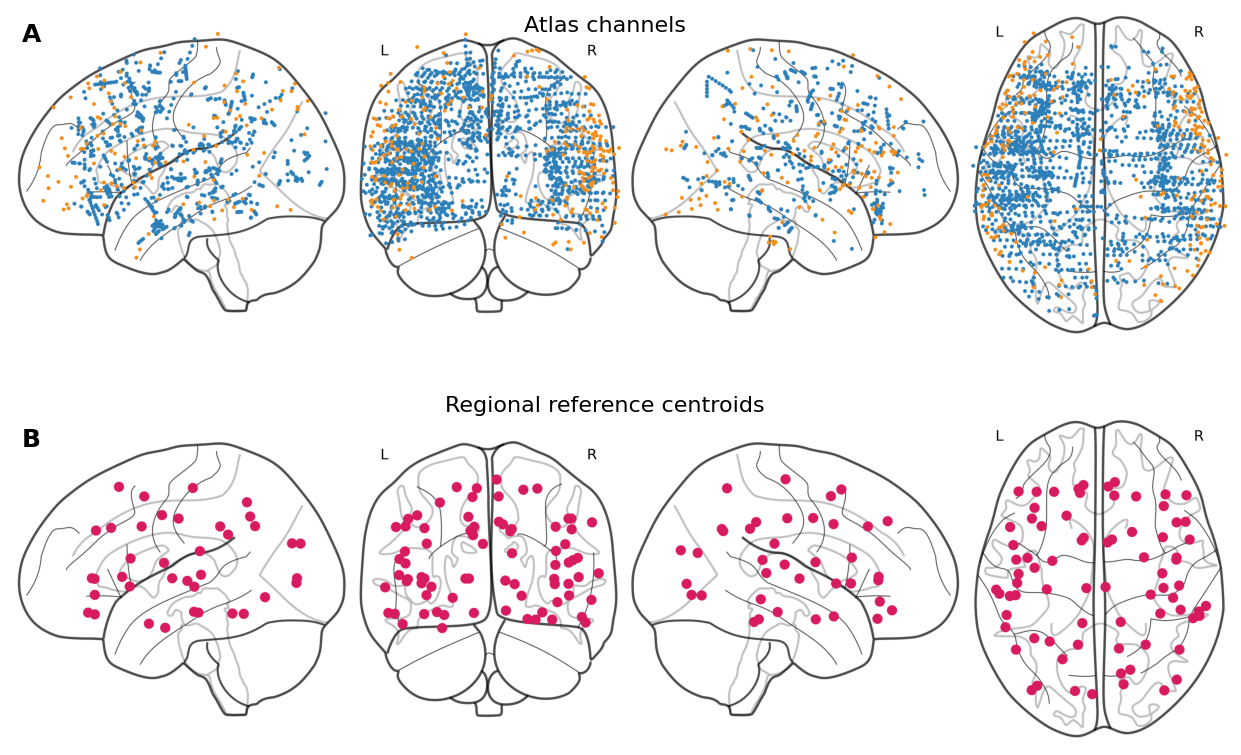

Saved combined PNG to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_and_centroids.png
Saved combined PDF to: /Users/daniel/PhD/spectral-comparison/code/notebooks/figures/outputs/frauscher_channels_and_centroids.pdf


In [2]:
# ----------------------------
# 3) Combine saved PNGs
# ----------------------------
img1 = mpimg.imread(channels_png)
img2 = mpimg.imread(centroids_png)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), facecolor="white")

axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

# Panel labels
axes[0].text(
    0.01, 0.96, "A",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left",
)

axes[1].text(
    0.01, 0.96, "B",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top",
    ha="left",
)

# Row titles, centered and placed closer to each panel
fig.text(
    0.5, 0.94, "Atlas channels",
    ha="center", va="center",
    fontsize=16
)

fig.text(
    0.5, 0.465, "Regional reference centroids",
    ha="center", va="center",
    fontsize=16
)

plt.subplots_adjust(
    left=0.03,
    right=0.99,
    top=0.96,
    bottom=0.04,
    hspace=0.22
)

combined_png = output_dir / "frauscher_channels_and_centroids.png"
combined_pdf = output_dir / "frauscher_channels_and_centroids.pdf"

plt.savefig(combined_png, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(combined_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved combined PNG to: {combined_png}")
print(f"Saved combined PDF to: {combined_pdf}")